<a href="https://colab.research.google.com/github/viegz11/DataScience_Learn/blob/main/fiat500.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd # Data Manupulation
import pickle # Store my model in my google Drive
import warnings #Highlight the issue
warnings.filterwarnings("ignore")


In [15]:
df = pd.read_csv("/content/fiat500.csv")
df.head()

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
0,1,lounge,51,882,25000,1,44.907242,8.611560,8900
1,2,pop,51,1186,32500,1,45.666359,12.241890,8800
2,3,sport,74,4658,142228,1,45.503300,11.417840,4200
3,4,lounge,51,2739,160000,1,40.633171,17.634609,6000
4,5,pop,73,3074,106880,1,41.903221,12.495650,5700


In [16]:
df.isnull().sum()

,0
ID,0
model,0
engine_power,0
age_in_days,0
km,0
previous_owners,0
lat,0
lon,0
price,0


In [17]:
list(df)

['ID',
 'model',
 'engine_power',
 'age_in_days',
 'km',
 'previous_owners',
 'lat',
 'lon',
 'price']

In [18]:
df['previous_owners'].unique()

array([1, 2, 3, 4])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               1520 non-null   int64  
 1   model            1520 non-null   object 
 2   engine_power     1520 non-null   int64  
 3   age_in_days      1520 non-null   int64  
 4   km               1520 non-null   int64  
 5   previous_owners  1520 non-null   int64  
 6   lat              1520 non-null   float64
 7   lon              1520 non-null   float64
 8   price            1520 non-null   int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 107.0+ KB


In [20]:
df.groupby(['model']).count()

,ID,engine_power,age_in_days,km,previous_owners,lat,lon,price
model,,,,,,,,
lounge,1079,1079,1079,1079,1079,1079,1079,1079
pop,356,356,356,356,356,356,356,356
sport,85,85,85,85,85,85,85,85


In [21]:
df.describe()

,ID,engine_power,age_in_days,km,previous_owners,lat,lon,price
count,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000
mean,768.854605,51.915132,1657.190789,53602.474342,1.123684,43.539485,11.571552,8564.311842
std,443.599478,4.010360,1290.870689,40181.202940,0.415901,2.137960,2.332344,1942.771619
min,1.000000,51.000000,366.000000,1232.000000,1.000000,36.855839,7.245400,2500.000000
25%,383.750000,51.000000,670.000000,20000.000000,1.000000,41.794763,9.505090,7100.000000
50%,769.500000,51.000000,1066.000000,39162.000000,1.000000,44.394096,11.869260,9000.000000
75%,1151.250000,51.000000,2623.750000,80000.000000,1.000000,45.467960,12.786127,10000.000000
max,1538.000000,77.000000,4658.000000,235000.000000,4.000000,46.795612,18.365520,11100.000000


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

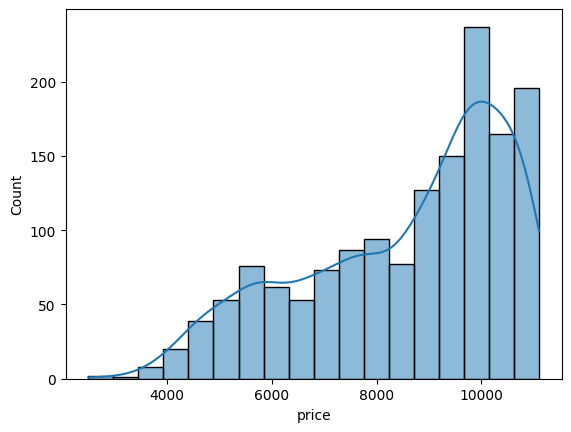

In [23]:
sns.histplot(df['price'], kde=True)
plt.show()

In [24]:
df.groupby('model')[
    ['engine_power','age_in_days','km','price']
].mean()

,engine_power,age_in_days,km,price
model,,,,
lounge,51.573679,1442.655236,47056.647822,8939.201112
pop,52.089888,1911.101124,61482.769663,7978.851124
sport,55.517647,3317.094118,103691.435294,6257.470588


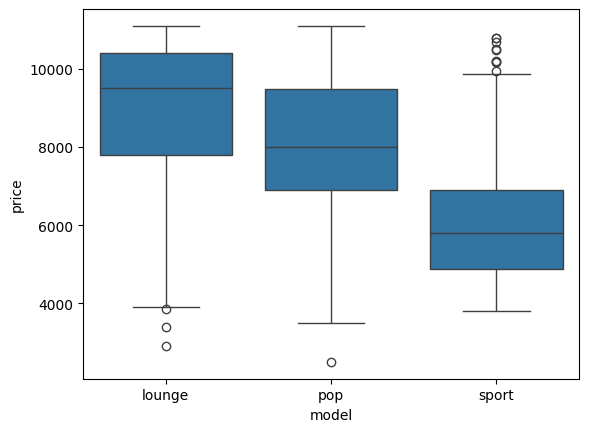

In [25]:
sns.boxplot(x='model', y='price', data=df)
plt.show()

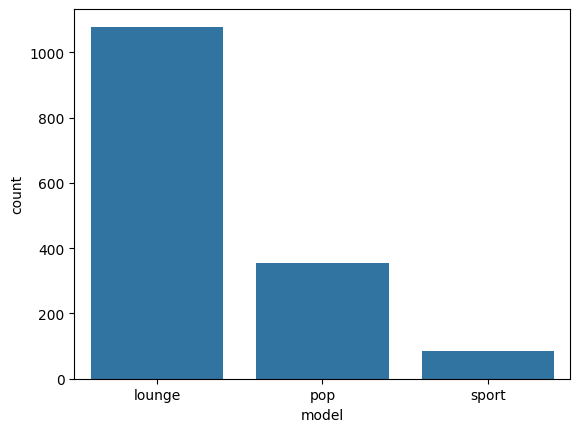

In [26]:
sns.countplot(x='model', data=df)
plt.show()

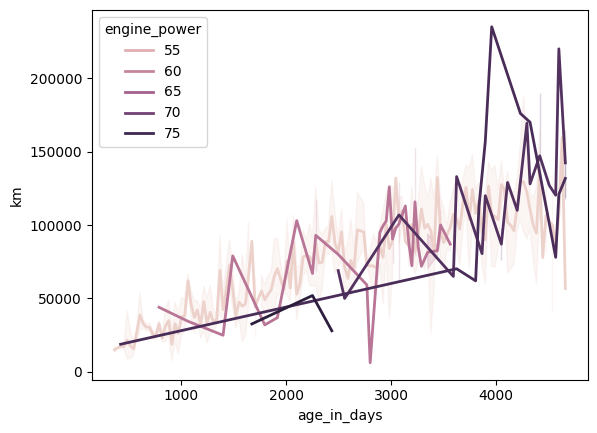

In [27]:
sns.lineplot(x="age_in_days", y="km",hue="engine_power",lw=2, data=df)
plt.show()

<Axes: >

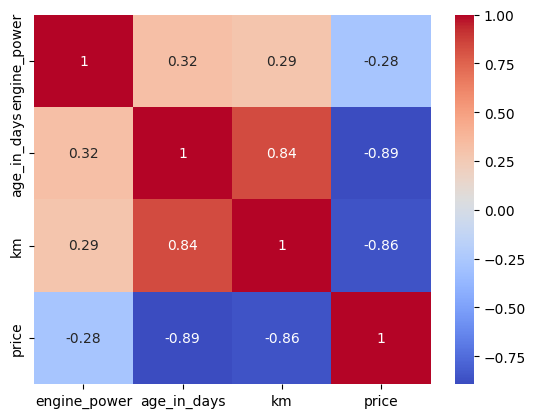

In [28]:
corr = df[['engine_power','age_in_days','km','price']].corr() # Relation betwee two columns

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

<Axes: >

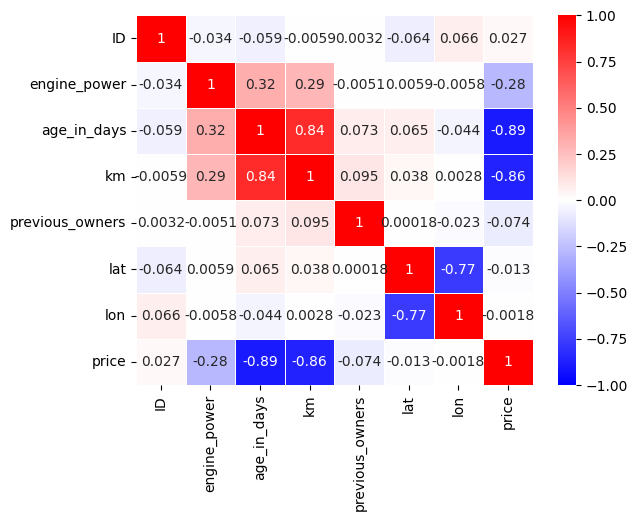

In [29]:
corr1 = df.drop('model',axis=1).corr() # Relation betwee two columns

sns.heatmap(corr1,
            vmax=1,
            vmin=-1,
            annot=True,
            linewidths=.5,
            cmap='bwr')

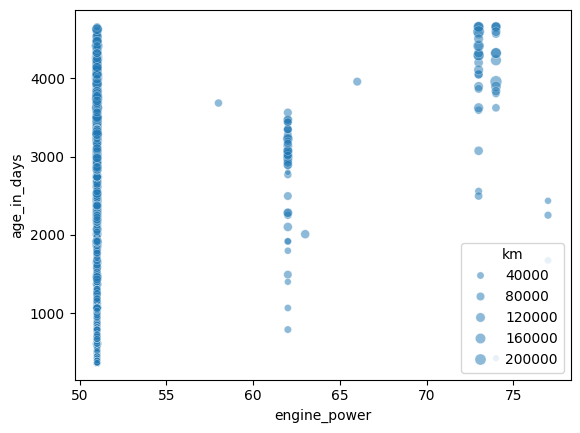

In [30]:
sns.scatterplot(
 x="engine_power",
 y="age_in_days",
 size="km",
 alpha=0.5,
 data=df
)
plt.show()

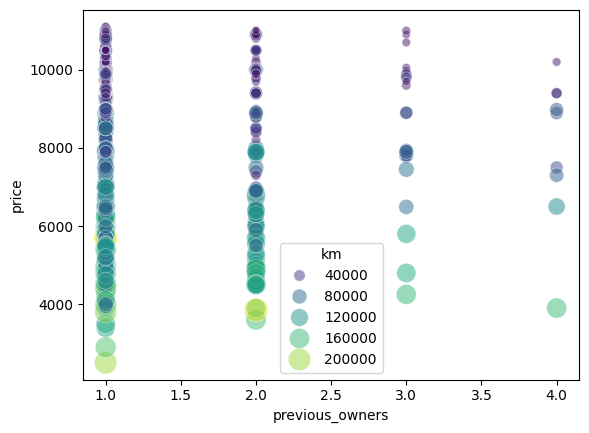

In [31]:
sns.scatterplot(
    x="previous_owners",
    y="price",
    size="km",
    hue="km",
    alpha=0.5,
    sizes=(20, 300),        # min and max marker size
    palette="viridis",      # color map
    data=df
)

plt.show()

In [32]:
df1 = df.drop(['lat','lon','ID'],axis=1)

In [33]:
df2=pd.get_dummies(df1,dtype=int)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   engine_power     1520 non-null   int64
 1   age_in_days      1520 non-null   int64
 2   km               1520 non-null   int64
 3   previous_owners  1520 non-null   int64
 4   price            1520 non-null   int64
 5   model_lounge     1520 non-null   int64
 6   model_pop        1520 non-null   int64
 7   model_sport      1520 non-null   int64
dtypes: int64(8)
memory usage: 95.1 KB


Data Modeling

In [34]:
x = df2.drop("price", axis=1) #Input Parameters
y = df2["price"] #Output Parameters
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [35]:
y_train.shape

(1140,)

# Linear Regression

In [36]:
from sklearn.linear_model import LinearRegression #ridge, lasso
reg = LinearRegression() # creating object of LinearRegression
reg.fit(x_train,y_train) # Training and fitting LR object using training data

LinearRegression()

In [37]:
ypred=reg.predict(x_test)
ypred

array([ 9729.69625708,  9937.41126928,  6582.87129739, 10304.73464849,
        9176.17250908,  6799.38502724,  9754.52809059, 10090.96606825,
        9700.24537686,  9518.16428725,  9663.58130949,  9304.30380049,
        9482.48354786,  8664.71972622, 10413.58499596,  7217.98392994,
        6989.62597098,  9883.56145172,  9769.94282679,  7737.46544822,
        4413.96033824,  5090.41695839,  9042.24962764, 10079.4991416 ,
        9331.94014948,  8382.45531674, 10035.2280513 ,  9917.9329579 ,
       10349.95877822,  8550.20359778, 10369.60606298, 10018.19132676,
        8845.37070425,  9617.89517499,  5487.53162973,  8305.88591242,
        9759.0700114 ,  9141.26020284,  8055.20465908, 10064.7716533 ,
        6986.44184807,  7034.80950499,  5723.86516715,  9420.91716426,
        5791.41857215,  8725.74654183,  9893.94506126, 10456.07200853,
        6410.45019883, 10317.49422821,  6398.32484326, 10082.21952774,
        9885.16122012,  5496.2899651 , 10075.07311145,  9832.33860952,
      

In [38]:
y_test

,price
461,9980
1314,9600
1472,6800
744,9890
247,10500
...,...
952,6800
1468,9980
478,9450
188,10670


In [39]:
from sklearn.metrics import r2_score
r2_score(y_test,ypred)

0.8342208439170529

In [40]:
from sklearn.metrics import mean_absolute_percentage_error as mape # Error in the dataset

mape_value= mape(y_test, ypred)
mape_value

0.07945576928196096

In [41]:
from sklearn.metrics import mean_squared_error as mse # Error in the mape
mse_value=mse(y_test, ypred)
mse_value**.5                                         # find square root

814.8792055118192

In [42]:
x_test

,engine_power,age_in_days,km,previous_owners,model_lounge,model_pop,model_sport
461,51,731,36303,1,1,0,0
1314,51,578,32057,1,1,0,0
1472,51,2527,108000,1,0,1,0
744,51,456,17253,1,1,0,0
247,51,1858,12000,2,1,0,0
...,...,...,...,...,...,...,...
952,51,2831,83000,1,0,1,0
1468,51,731,12000,1,1,0,0
478,51,790,41572,2,1,0,0
188,51,670,45000,1,0,1,0


In [43]:
new=[[51,2197,70000,1,1,0,0],[51,3127,100000,1,1,0,0]]
reg.predict(new)

array([7862.85093123, 6526.23943706])

In [44]:
Results=pd.DataFrame(columns=['Price','Predicted'])
Results['Price']=y_test
Results['Predicted']=ypred
Results['Id'] = Results.index
Results['km']=x_test['km']

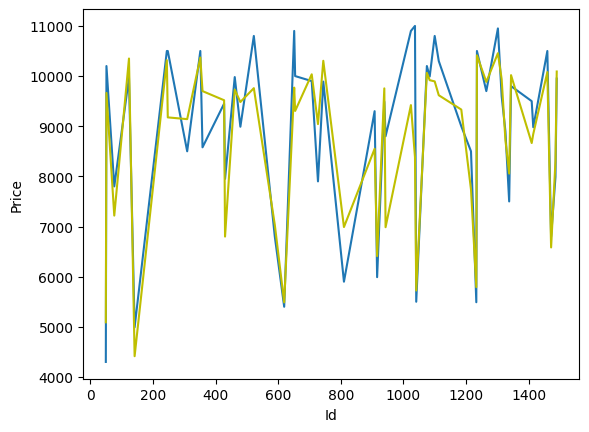

In [45]:
sns.lineplot(x='Id',y='Price',data=Results.head(50))
sns.lineplot(x='Id',y='Predicted',color='y',data=Results.head(50))
plt.show()

# Ridge Regression

In [46]:
from sklearn.model_selection import GridSearchCV # Find the parameters
from sklearn.linear_model import Ridge

In [47]:
alpha = [1e-15,1e-10, 1e-8, 1e-4, 1e-3, 1e-2, 1,5,10, 20, 30]
ridge=Ridge()
parameters={'alpha':alpha}
ridge_regressor=GridSearchCV(ridge,parameters)
ridge_regressor.fit(x_train, y_train)

GridSearchCV(estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01, 1,
                                   5, 10, 20, 30]})

In [48]:
ridge_regressor.best_params_

{'alpha': 20}

In [49]:
ridge=Ridge(alpha=20)
ridge.fit(x_train,y_train)
ypred=ridge.predict(x_test)
ypred

array([ 9726.26384281,  9933.94008917,  6596.59243881, 10301.18125108,
        9174.21759239,  6796.53282965,  9751.08393342, 10087.44451519,
        9696.81760304,  9514.78025507,  9640.46154173,  9300.90960511,
        9495.61839397,  8661.48555773, 10410.00933608,  7198.18770196,
        6986.5910107 ,  9880.09826742,  9766.50578506,  7734.40819618,
        4415.82437867,  5068.11044523,  9040.39885975, 10075.97774629,
        9328.56991847,  8395.80836147, 10031.71506633,  9914.45827122,
       10346.39930324,  8546.98724683, 10366.04444134, 10031.23735955,
        8842.13242969,  9614.48834899,  5484.93771803,  8319.30313256,
        9735.95106191,  9154.49030893,  8068.61280488, 10077.80583723,
        6983.52257001,  7048.40179705,  5701.44782909,  9417.56890586,
        5805.25155103,  8723.97904349,  9890.47647649, 10452.48839214,
        6407.59898693, 10315.38620937,  6375.80868903, 10078.72273257,
        9881.69201862,  5511.59072293, 10071.55845227,  9828.87465931,
      

In [50]:
from sklearn.metrics import r2_score
r2_score(y_test,ypred)

0.8344294648067309

In [51]:
from sklearn.metrics import mean_absolute_percentage_error as mape
mape(y_test,ypred)

0.07945036332560458

In [52]:
from sklearn.metrics import mean_squared_error as mse
mse_value=mse(y_test,ypred)
mse_value**.5

814.3663112918267

In [53]:
new=[[51,2197,70000,1,1,0,0],[51,3127,100000,1,1,0,0]]
reg.predict(new)

array([7862.85093123, 6526.23943706])

In [54]:
Results=pd.DataFrame(columns=['Price','Predicted'])
Results['Price']=y_test
Results['Predicted']=ypred
Results['Id'] = Results.index

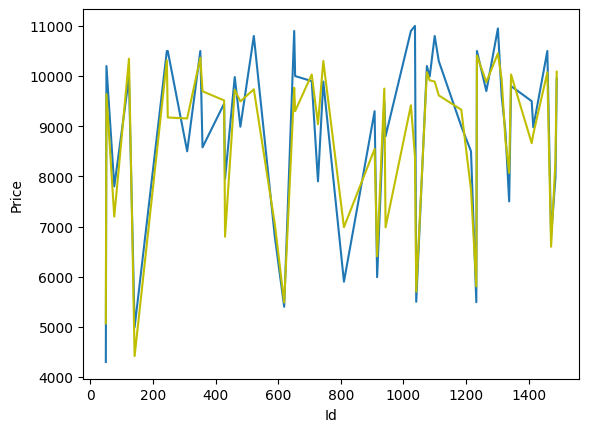

In [55]:
Results['Id'] = Results.index
sns.lineplot(x='Id',y='Price',data=Results.head(50))
sns.lineplot(x='Id',y='Predicted',color='y',data=Results.head(50))
plt.show()

# Random Forest


In [57]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
reg=RandomForestRegressor()
n_estimators=[25,50,75,100,125,150,175,200] # number of decision tree in the model
criterion=['squared_error']
max_depth=[3,5,10]
parameters={'n_estimators':n_estimators,'criterion':criterion,'max_depth':max_depth}
RFC_reg=GridSearchCV(reg,parameters)
RFC_reg.fit(x_train,y_train)


GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'criterion': ['squared_error'],
                         'max_depth': [3, 5, 10],
                         'n_estimators': [25, 50, 75, 100, 125, 150, 175, 200]})

In [59]:
RFC_reg.best_params_

{'criterion': 'squared_error', 'max_depth': 5, 'n_estimators': 150}